Working in: /Users/mauriciotano/projects/jax-cfd-tests/notebooks/decay_heat_code/examples
Root directory: /Users/mauriciotano/projects/jax-cfd-tests/notebooks/decay_heat_code
Python path: ['/Users/mauriciotano/projects/jax-cfd-tests/notebooks/decay_heat_code', '/Users/mauriciotano/projects/jax-cfd-tests/notebooks/decay_heat_code', '/Users/mauriciotano/projects/jax-cfd-tests/notebooks/decay_heat_code/examples', '/Users/mauriciotano/miniforge/envs/scientific_env/lib/python312.zip', '/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12', '/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/lib-dynload', '', '/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages']


/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn develo

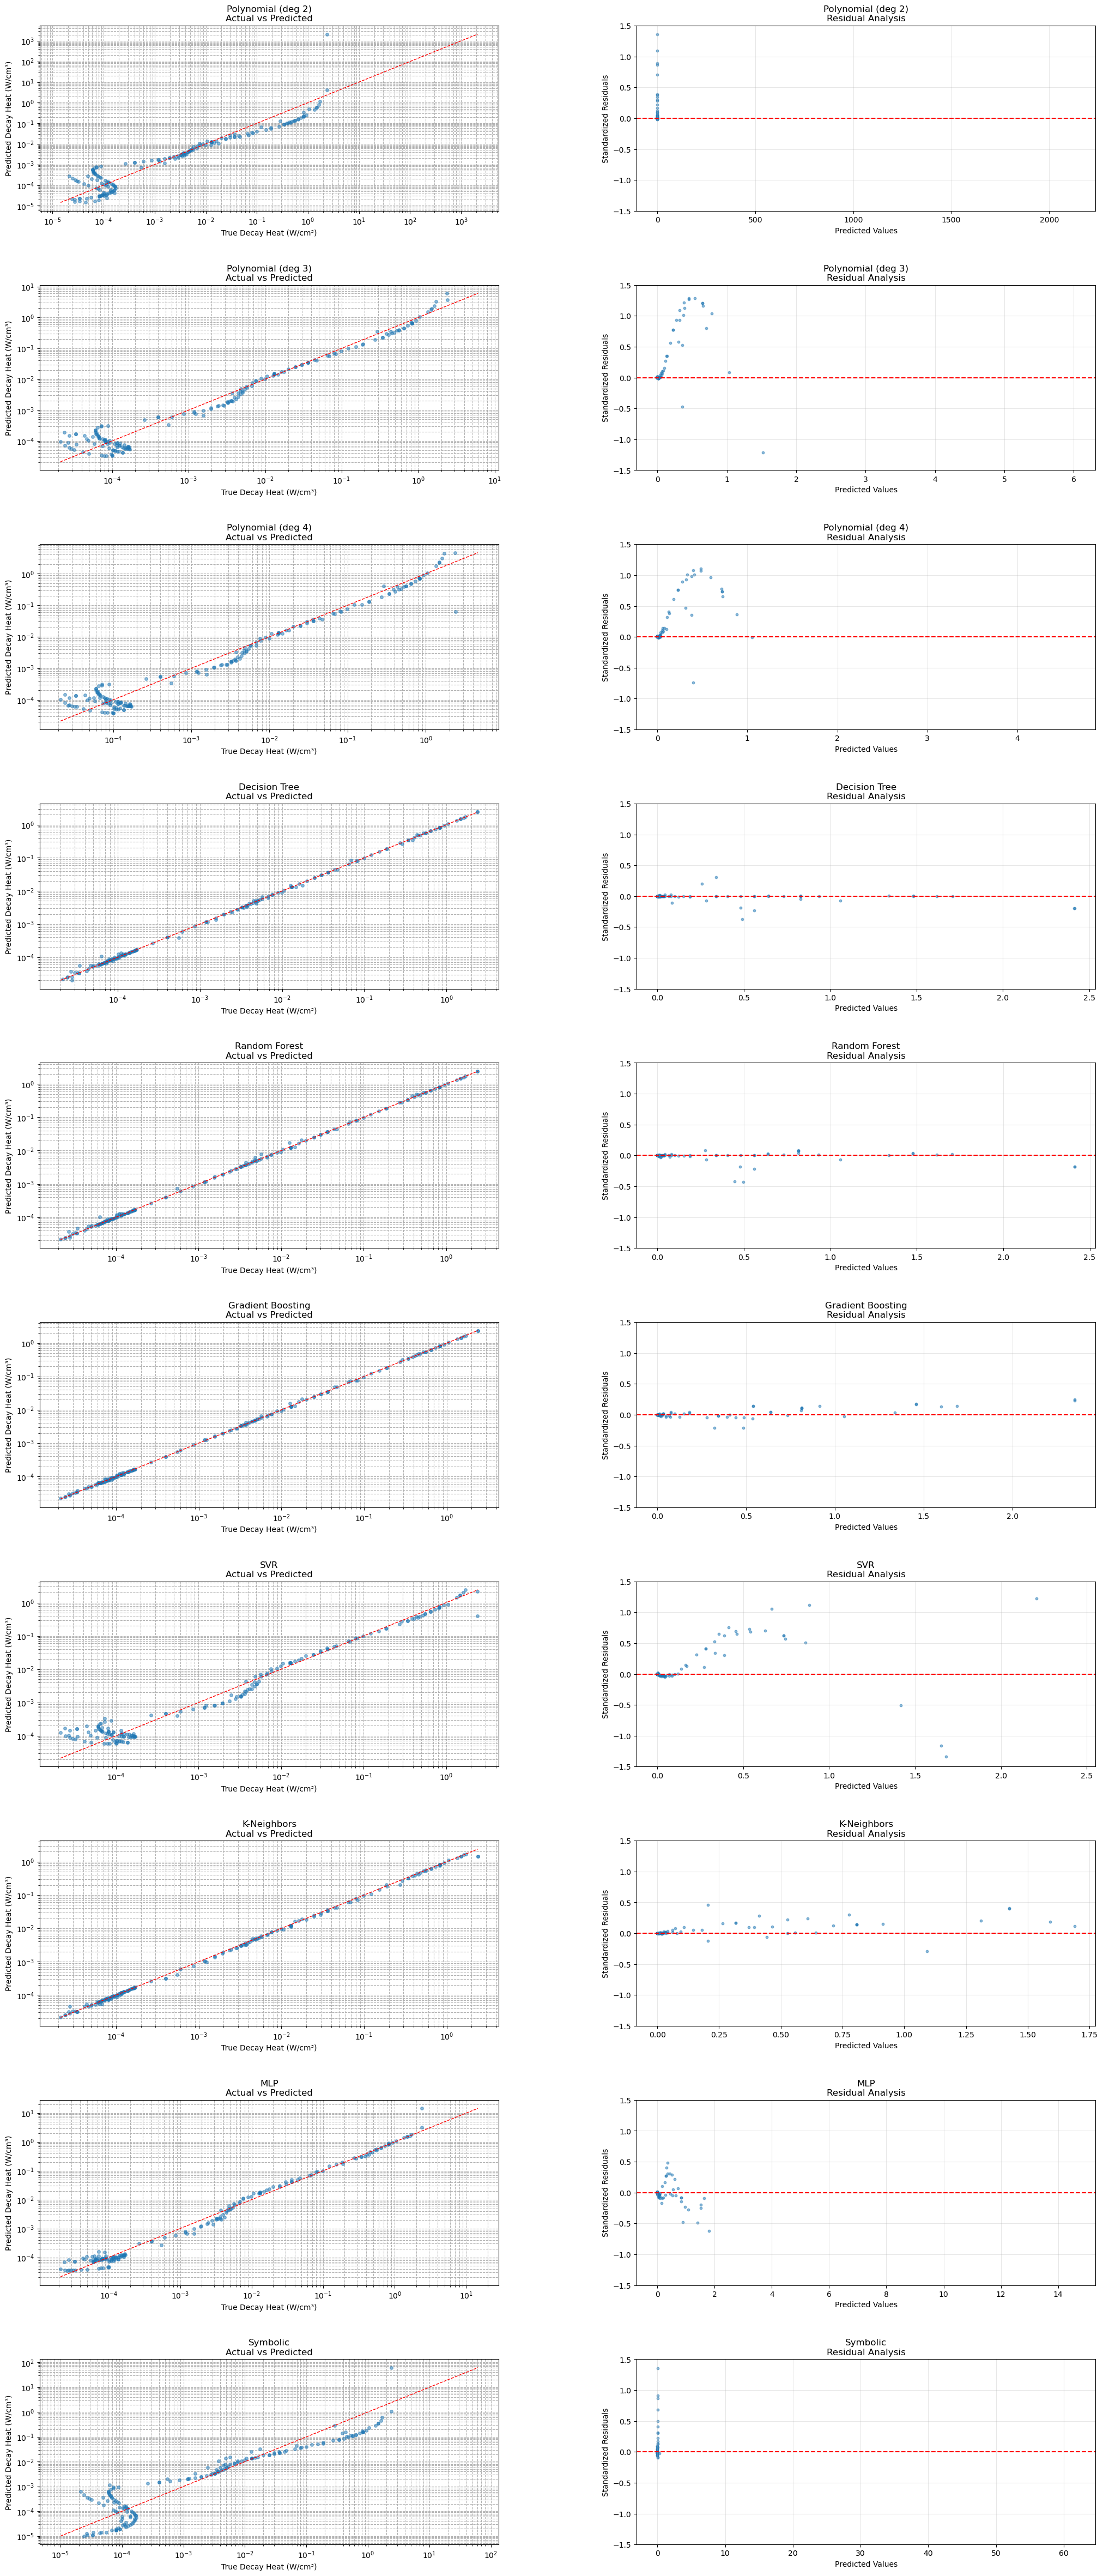

interactive(children=(Dropdown(description='Model:', options=('Polynomial (deg 2)', 'Polynomial (deg 3)', 'Pol…

In [3]:
# Updated Jupyter notebook setup
import os
import sys
import warnings

# Filter out specific warnings if needed
warnings.filterwarnings('ignore', category=UserWarning)

# Add package directory to path (Jupyter-safe version)
NOTEBOOK_DIR = os.getcwd()  # Gets current notebook directory
ROOT_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
sys.path.insert(0, ROOT_DIR)

# Now import your modules
from data_loader import DataLoader
from model_trainer import ModelTrainer
from visualizer import Visualizer

print(f"Working in: {NOTEBOOK_DIR}")
print(f"Root directory: {ROOT_DIR}")
print(f"Python path: {sys.path}")

# Load and prepare data
loader = DataLoader(ROOT_DIR + "/data/FLi_FTh4_FU4.pickle")
cases, df = loader.load_and_preprocess()

# Train models
trainer = ModelTrainer(df)
trainer.train_and_evaluate()

# Generate comprehensive reports
viz = Visualizer(trainer)

# 1. Full model evaluation report
viz.create_model_evaluation_report(save_path="model_report.png")

# 2. Interactive prediction explorer
viz.create_interactive_plot()

In [ ]:
print(trainer.results.keys())

for key in trainer.results.keys():
  print(key)
  print('RMSE: {0:.2e} - R2: {1:.3f}'.format(trainer.results[key]['test_mse'] / len(trainer.results[key]['y_pred']), trainer.results[key]['test_r2']))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mauriciotano/miniforge/envs/scientific_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2

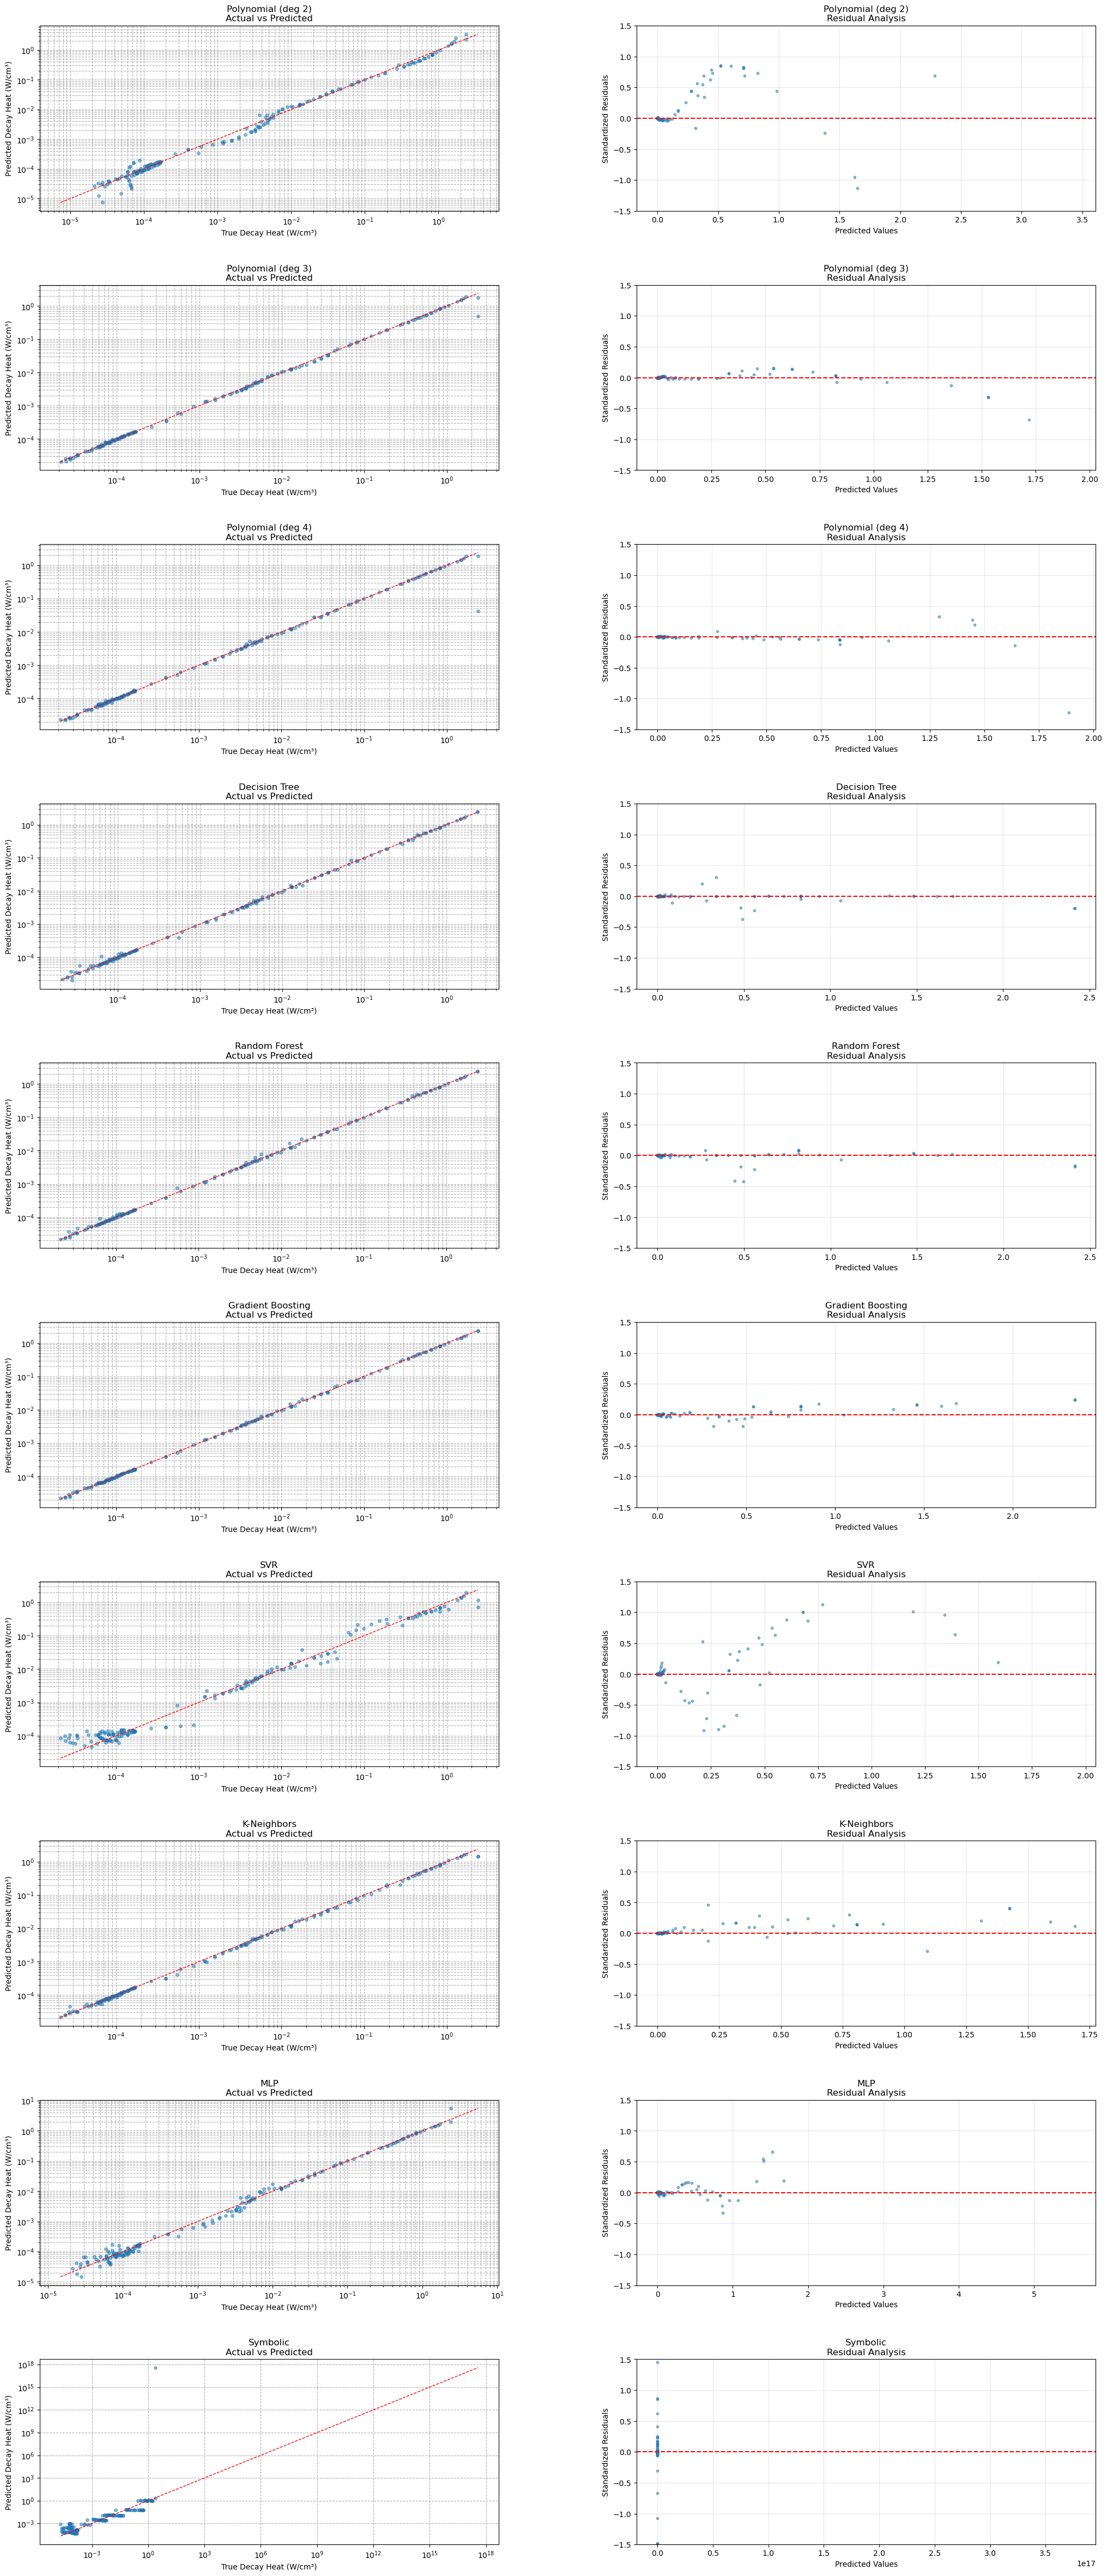

interactive(children=(Dropdown(description='Model:', options=('Polynomial (deg 2)', 'Polynomial (deg 3)', 'Pol…

In [1]:
# Updated Jupyter notebook setup
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)

NOTEBOOK_DIR = os.getcwd()
ROOT_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
sys.path.insert(0, ROOT_DIR)

from data_loader import DataLoader
from model_trainer import EnhancedModelTrainer  # Changed import
from visualizer import Visualizer

# Load data
loader = DataLoader(os.path.join(ROOT_DIR, "data/FLi_FTh4_FU4.pickle"))
cases, df = loader.load_and_preprocess()

# Train models with regional optimization
trainer = EnhancedModelTrainer(df, max_regions=10)  # Now using enhanced trainer
results = trainer.train_and_evaluate()

# Visualize results
viz = Visualizer(trainer)

# Generate reports
viz.create_model_evaluation_report(save_path="optimized_model_report.png")

# Interactive plot with region-optimized models
viz.create_interactive_plot()

In [2]:
print(trainer.results.keys())

# Display optimal regions
print("\nOptimal Regions Configuration:")
for model_name, res in trainer.results.items():
    if res is not None:
        print(f"{model_name}: {res.get('optimal_regions', 1)} regions")

for key in trainer.results.keys():
  print(key)
  print('RMSE: {0:.2e} - R2: {1:.3f}'.format(trainer.results[key]['test_mse'] / len(trainer.results[key]['y_pred']), trainer.results[key]['test_r2']))

dict_keys(['Polynomial (deg 2)', 'Polynomial (deg 3)', 'Polynomial (deg 4)', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVR', 'K-Neighbors', 'MLP', 'Symbolic'])

Optimal Regions Configuration:
Polynomial (deg 2): 3 regions
Polynomial (deg 3): 4 regions
Polynomial (deg 4): 7 regions
Decision Tree: 3 regions
Random Forest: 4 regions
Gradient Boosting: 9 regions
SVR: 4 regions
K-Neighbors: 1 regions
MLP: 3 regions
Symbolic: 8 regions
Polynomial (deg 2)
RMSE: 5.52e-04 - R2: 0.992
Polynomial (deg 3)
RMSE: 1.01e-04 - R2: 0.998
Polynomial (deg 4)
RMSE: 5.15e-04 - R2: 0.992
Decision Tree
RMSE: 4.27e-05 - R2: 0.999
Random Forest
RMSE: 3.27e-05 - R2: 1.000
Gradient Boosting
RMSE: 1.22e-05 - R2: 1.000
SVR
RMSE: 1.14e-03 - R2: 0.983
K-Neighbors
RMSE: 5.90e-05 - R2: 0.999
MLP
RMSE: 4.17e-04 - R2: 0.994
Symbolic
RMSE: 5.48e-02 - R2: 0.174
